# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### **Goal**
Determine which features have the most influence over the sale price of used cars. The goal is to build an understanding of the data and to be able to interpret the value of various independent variables in how much they affect the sale price as a dependent variable.

#### **Methodology**
Develop a supervised regression model targeting the sale price of used vehicles, then interpret the fitted model through coefficient analyses to determine which features have the largest impact on sale price.

#### **Validation Strategy**
Use strategies such as a train-test split or k-fold cross validation and measuring the RMSE and MAE to determine the effectiveness of the fitted model not only against the training data but against simulated real-world data as well.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### Exploring the Data
The first steps in understanding the dataset is to examine the features. I will use dataframe.head() and dataframe.info() to get an understanding of the shape of the data. I will then attempt to discover how much of the data is missing, looking for columns that have a significant number of NaN values. I will also put together plots like histograms of various features of the dataset to start to understand the distribution of values in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/vehicles.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [3]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


               count    percent
id                 0   0.000000
region             0   0.000000
price              0   0.000000
year            1205   0.282281
manufacturer   17646   4.133714
model           5277   1.236179
condition     174104  40.785232
cylinders     177678  41.622470
fuel            3013   0.705819
odometer        4400   1.030735
title_status    8242   1.930753
transmission    2556   0.598763
VIN           161042  37.725356
drive         130567  30.586347
size          306361  71.767476
type           92858  21.752717
paint_color   130203  30.501078
state              0   0.000000


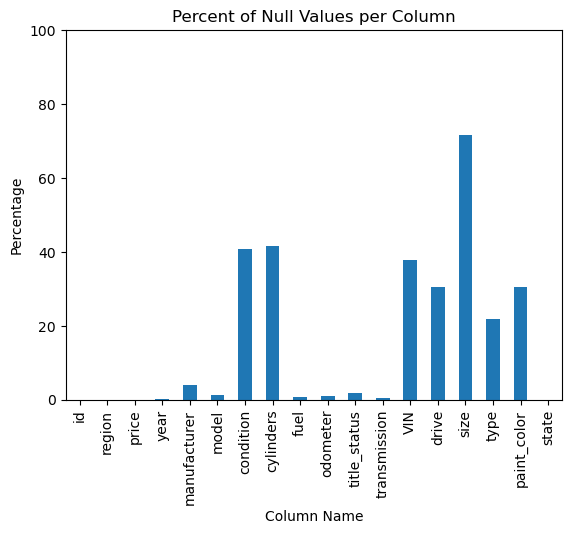

In [4]:
count_null = df.isnull().sum()
null_summary = pd.DataFrame({'count': count_null, 'percent': (count_null / len(df)) * 100})

print(null_summary)
null_summary['percent'].plot(kind='bar', ylim=(0, 100))
plt.title("Percent of Null Values per Column")
plt.xlabel("Column Name")
plt.ylabel("Percentage")
#plt.xticks(rotation=45)
plt.show()

In [5]:
df[df['price'] > 0]['price'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .995, .999])

count    3.939850e+05
mean     8.147763e+04
std      1.268064e+07
min      1.000000e+00
1%       1.500000e+02
5%       1.988000e+03
25%      7.000000e+03
50%      1.500000e+04
75%      2.759000e+04
95%      4.499900e+04
99%      6.874748e+04
99.5%    7.890000e+04
99.9%    1.234560e+05
max      3.736929e+09
Name: price, dtype: float64

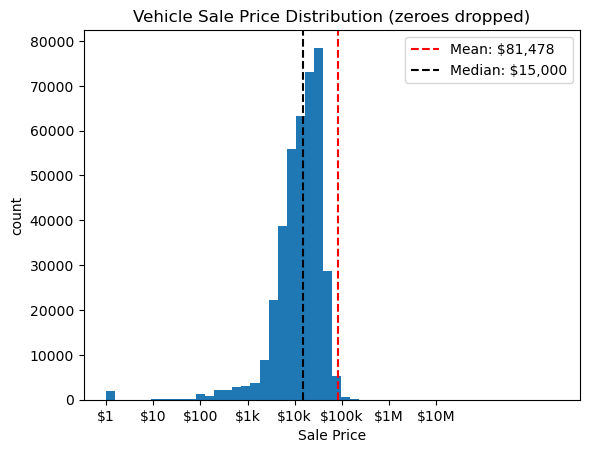

In [6]:
price = df[(df['price'] > 0)]['price']
log_price = np.log(price)

mean = price.mean()
median = price.median()

plt.hist(log_price, bins=50)
ticks = [np.log(v) for v in [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]]
labels = ['$1', '$10', '$100', '$1k', '$10k', '$100k', '$1M', '$10M']
plt.title("Vehicle Sale Price Distribution (zeroes dropped)")
plt.axvline(np.log(mean),   color='red',   linestyle='--', label=f'Mean: ${mean:,.0f}')
plt.axvline(np.log(median), color='black', linestyle='--', label=f'Median: ${median:,.0f}')
plt.xlabel("Sale Price")
plt.xticks(ticks, labels)
plt.ylabel("count")
plt.legend()
plt.show()
#log_price.head()

In [7]:
df['odometer'].describe()

count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64

In [8]:
df['year'].describe()

count    425675.000000
mean       2011.235191
std           9.452120
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

In [9]:
print("num unique models: %s" % df['model'].nunique())
print("num unique regions: %s" % df['region'].nunique())
print("num unique manufacturers: %s" % df['manufacturer'].nunique())
print("num unique conditions: %s" % df['condition'].nunique())
print("num unique cylinders: %s" % df['cylinders'].nunique())
print("num unique fuels: %s" % df['fuel'].nunique())
print("num unique title_status: %s" % df['title_status'].nunique())
print("num unique transmissions: %s" % df['transmission'].nunique())
print("num unique drives: %s" % df['drive'].nunique())
print("num unique types: %s" % df['type'].nunique())
print("num unique paint_colors: %s" % df['paint_color'].nunique())
print("num unique states: %s" % df['state'].nunique())

num unique models: 29649
num unique regions: 404
num unique manufacturers: 42
num unique conditions: 6
num unique cylinders: 8
num unique fuels: 5
num unique title_status: 6
num unique transmissions: 3
num unique drives: 3
num unique types: 13
num unique paint_colors: 12
num unique states: 51


In [10]:
df['size'].unique()

array([nan, 'full-size', 'mid-size', 'compact', 'sub-compact'],
      dtype=object)

In [11]:
drop_null_rows = df.dropna(subset=['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission'])
dropped_percent = ((len(df) - len(drop_null_rows)) / len(df)) * 100
print("percent of rows dropped with null values: %s" % dropped_percent)

percent of rows dropped with null values: 8.7321964017991


In [12]:
nulls = df['odometer'].isna().sum()
zeros = (df['odometer'] == 0).sum()
high  = (df['odometer'] > 400_000).sum()
print("odometer values")
print(f"null: {nulls:,} ({nulls/len(df):.2%})")
print(f"zero: {zeros:,} ({zeros/len(df):.2%})")
print(f">400k: {high:,} ({high/len(df):.2%})")

odometer values
null: 4,400 (1.03%)
zero: 1,965 (0.46%)
>400k: 1,702 (0.40%)


#### **Exploration Conclusions**

##### **Columns**
The dataset contains 18 columns: id, region, price, year, manufacturer, model, condition, cylinders, fuel, odometer, title_status, transmission, VIN, drive, size, type, paint_color, state

##### **Null Values**
My initial analysis shows that some columns of this dataset have a significant percentage of null values. These are 'size', 'condition', 'cylinders', 'VIN', 'drive', 'type' and 'paint_color', with 'size' having the most null values out of all columns. I believe that the 'VIN' column can be dropped completely as it likely has no real impact on the sale price, 'size' can also likely be dropped as it is about 72% null values. All of the other columns that have a significant number of null values will likely have their nulls replaced with a 'missing' value, I think it may be possible that the fact that a listing is missing one or more of these values may have an impact on how much customers are willing to pay for them.

Some columns contain more insignificant numbers of null values. these are 'year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status' and 'transmission'. All of these contain less than 5% null values and most of them contain ~1% null values, so I believe that it is possible to simply drop all of the rows that contain null values for these columns. Dropping the null values in these columns only reduces the total rows in the dataset by 8%.

##### **Price**
The price data will need to be cleaned up considerably. About 5% of the given prices are zero, and there are a significant number of outlier values, such as the largest price which is $3.7B. The data will need to be clipped to get rid of the zeroes and the outliers. The 99th percentile price is $68,747 so I believe that this would be a fair upper bound to cut off the higher outliers. The analysis above used a log transformation of the price data to make it more readable in plots, this may or may not be necessary after removing all of the extreme outliers.

##### **Year**
The minimum year value of 1900 seems to be a placeholder or default value, so these entries should be filtered out as well. After dopping anything older than about 1920, I will also engineer a new column for 'age', this will make linear regression models easier to build because a raw 'year' value will be difficult for the model to directly learn from, whereas the model can directly use an 'age' value mathematically.

I'll also note that while in general, newer cars are worth more than older ones, this is not the case for 'classic' cars. Older classic cars can actually increase in price as they get older, so a linear model with have difficulty modeling this correctly. To solve for this, I plan to use clustering algorithms to hopefully identify these kinds of categories and account for them.

##### **Odometer**
The max odometer value of 10,000,000 is not a feasible value for a real vehicle, so this will also need to be filtered. Entries with an odometer value of zero are most likely either typos or default values, since a used car should not ever be brand new. Because of this, I will drop all rows with an odometer value of zero. For the impossibly high odometer values I will just clip their values to the 99.5 percentile odometer value of the dataset (about 300,000 miles).

##### **Model, Region, Manufacturer and States**
These categorical features will need to be encoded in order to be useful to the model. In particular, the 'model' feature has almost 30,000 unique values, so one-hot encoding for this feature will not be feasible, a different encoding method like target encoding will need to be used.

##### **All Other Categorical Features**
All of the other categorical features other than 'Model', 'Region', 'Manufacturer' and 'States' will be encoded using one-hot encoding.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [13]:
# dropping unneccessary columns VIN and size
vehicles_clean = df.drop(columns=['VIN', 'size', 'id', 'region'])

# drop rows containing null from columns with few nulls
vehicles_clean = vehicles_clean.dropna(subset=['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission'])

# replace null values in some columns with 'missing'
vehicles_clean = vehicles_clean.fillna("missing")

vehicles_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389604 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         389604 non-null  int64  
 1   year          389604 non-null  float64
 2   manufacturer  389604 non-null  object 
 3   model         389604 non-null  object 
 4   condition     389604 non-null  object 
 5   cylinders     389604 non-null  object 
 6   fuel          389604 non-null  object 
 7   odometer      389604 non-null  float64
 8   title_status  389604 non-null  object 
 9   transmission  389604 non-null  object 
 10  drive         389604 non-null  object 
 11  type          389604 non-null  object 
 12  paint_color   389604 non-null  object 
 13  state         389604 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 44.6+ MB


In [14]:
# filter the price data, remove zeroes and prices above the 99th percentile
price_percentile_99 = vehicles_clean['price'].describe(percentiles=[.99])['99%']
vehicles_clean = vehicles_clean[(vehicles_clean['price'] > 0) & (vehicles_clean['price'] < price_percentile_99)]

vehicles_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 357095 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         357095 non-null  int64  
 1   year          357095 non-null  float64
 2   manufacturer  357095 non-null  object 
 3   model         357095 non-null  object 
 4   condition     357095 non-null  object 
 5   cylinders     357095 non-null  object 
 6   fuel          357095 non-null  object 
 7   odometer      357095 non-null  float64
 8   title_status  357095 non-null  object 
 9   transmission  357095 non-null  object 
 10  drive         357095 non-null  object 
 11  type          357095 non-null  object 
 12  paint_color   357095 non-null  object 
 13  state         357095 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 40.9+ MB


In [15]:
# filter the odometer values, drop zeroes and cap values above the 99.5th percentile
od_percentile_995 = vehicles_clean['odometer'].describe(percentiles=[.995])['99.5%']
vehicles_clean = vehicles_clean[vehicles_clean['odometer'] > 0]
vehicles_clean['odometer'] = vehicles_clean['odometer'].clip(upper=od_percentile_995)

print(od_percentile_995)
print(vehicles_clean['odometer'].describe())
vehicles_clean.info()

303295.65999999933
count    356455.000000
mean      93430.700085
std       63049.200785
min           1.000000
25%       39385.000000
50%       88241.000000
75%      136000.000000
max      303295.660000
Name: odometer, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 356455 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         356455 non-null  int64  
 1   year          356455 non-null  float64
 2   manufacturer  356455 non-null  object 
 3   model         356455 non-null  object 
 4   condition     356455 non-null  object 
 5   cylinders     356455 non-null  object 
 6   fuel          356455 non-null  object 
 7   odometer      356455 non-null  float64
 8   title_status  356455 non-null  object 
 9   transmission  356455 non-null  object 
 10  drive         356455 non-null  object 
 11  type          356455 non-null  object 
 12  paint_color   356455 non-null  object 

In [16]:
# drop rows with year older than 1920
vehicles_clean = vehicles_clean[vehicles_clean['year'] > 1920]

# create a new column for 'age' and drop the 'year'
current_year = 2026
vehicles_clean['age'] = current_year - vehicles_clean['year']
vehicles_clean = vehicles_clean.drop(columns=['year'])

vehicles_clean.head()

,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,age
27,33590,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,missing,pickup,white,al,12.0
28,22590,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,missing,pickup,blue,al,16.0
29,39590,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,missing,pickup,red,al,6.0
30,30990,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,missing,pickup,red,al,9.0
31,15000,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,13.0


In [17]:
vehicles_clean['cylinders'].unique()

array(['8 cylinders', '6 cylinders', 'missing', '4 cylinders',
       '5 cylinders', '10 cylinders', '3 cylinders', 'other',
       '12 cylinders'], dtype=object)

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# declare all of the features that will be one-hot encoded
oh_features = ['condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'manufacturer', 'state']

transformer = ColumnTransformer(
  transformers=[
    ('oh_encoder', OneHotEncoder(sparse_output=False), oh_features)
  ],
  remainder='passthrough',
  verbose_feature_names_out=False
)

vehicles_ohe = pd.DataFrame(transformer.fit_transform(vehicles_clean), columns=transformer.get_feature_names_out(), index=vehicles_clean.index)
vehicles_ohe.head()

,condition_excellent,condition_fair,condition_good,condition_like new,condition_missing,condition_new,condition_salvage,cylinders_10 cylinders,cylinders_12 cylinders,cylinders_3 cylinders,...,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,price,model,odometer,age
27,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,33590,sierra 1500 crew cab slt,57923.0,12.0
28,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,22590,silverado 1500,71229.0,16.0
29,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,39590,silverado 1500 crew,19160.0,6.0
30,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,30990,tundra double cab sr,41124.0,9.0
31,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,15000,f-150 xlt,128000.0,13.0


In [21]:
from sklearn.model_selection import train_test_split

# split the price column into a separate dataframe
price = vehicles_ohe['price']
vehicles_ohe = vehicles_ohe.drop(columns=['price'])

# create train and test datasets
X_train, X_test, y_train, y_test = train_test_split(vehicles_ohe, price, test_size=0.2, random_state=42)

In [23]:
from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder(target_type='continuous', smooth='auto', random_state=42)

# fit_transform uses 5-fold cross-fitting on training data automatically (no leakage)
# transform on test uses the full-training-set encoding
X_train['model'] = encoder.fit_transform(X_train[['model']], y_train).ravel()
X_test['model']  = encoder.transform(X_test[['model']]).ravel()

X_train['model'] = X_train['model'].astype(float)
X_test['model']  = X_test['model'].astype(float)

X_train.head()

,condition_excellent,condition_fair,condition_good,condition_like new,condition_missing,condition_new,condition_salvage,cylinders_10 cylinders,cylinders_12 cylinders,cylinders_3 cylinders,...,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,model,odometer,age
80207,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12500.430130,122808.0,9.0
370907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18305.191147,20000.0,6.0
333632,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12743.604807,99999.0,68.0
36791,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21348.569400,13135.0,7.0
80648,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25365.978516,60783.0,12.0


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.